# Who will cancel, and who's worth saving?

A telecom company wants to stop customers from leaving. It can send a retention offer, but every offer costs money,
and many people who get one would have stayed anyway. Most churn projects stop at "the model is 80% accurate".
The real question is **who to send the offer to**. This notebook answers it with IBM's sample data for a
fictional telecom company: 7,043 customers, 26.5% of whom left.

**Short answer:**
1. **Contract type is the biggest warning sign.** New month-to-month customers (first 6 months) leave at 55%;
   two-year customers at 3%. Month-to-month customers account for 87% of the monthly revenue lost to churn.
2. **A simple logistic regression is as good as the fancier models** (AUC 0.843, vs 0.845 for a random forest and
   0.840 for gradient boosting), and its probabilities are well calibrated, which the decision step needs.
3. **Don't target everyone the model flags.** With a $60 offer that keeps 30% of would-be leavers, offering it to
   every customer *loses* $122,000, and the usual "risk above 50%" rule earns $85,000. Targeting only customers whose
   *expected profit* is positive (risk × chance the offer works × value of their bill > cost) earns **$92,000**.
4. **The 50% cut-off only works by luck.** Across 30 combinations of offer cost and success rate, the
   expected-profit rule beat it every time, by up to $128,000. When the offer is expensive and rarely works, the
   50% rule loses money, and the profit rule correctly targets almost no one.

In [1]:
import sys
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from churn import Offer, expected_profit, load, models, out_of_fold, policies  # noqa: E402
from style import AQUA, BLUE, BLUE_LIGHT, GRID, INK, INK_2, NEUTRAL, ORANGE, ORANGE_LIGHT, SURFACE, VIOLET, save, titles  # noqa: E402

con = duckdb.connect(str(ROOT / "data" / "telco.duckdb"), read_only=True)
sql = lambda q: con.sql(q).df()
X, y, raw = load(ROOT / "data" / "raw" / "Telco-Customer-Churn.csv")
pd.set_option("display.width", 200)

## 1. Data quality

In [2]:
sql("SELECT check_name, detail, passed FROM dq_results ORDER BY check_name")

,check_name,detail,passed
0,blank totals only for brand-new customers,"11 blank totals, 11 of them with tenure 0",True
1,charges in a plausible range,monthly 18.25-118.75,True
2,internet add-ons consistent with internet service,0 inconsistent rows,True
3,multiple lines consistent with phone service,0 inconsistent rows,True
4,one row per customer,"7043 rows, 7043 ids",True
5,rollup total matches customer count,7043 vs 7043,True
6,total charges consistent with tenure x monthly...,0 customers outside 0.5x-2x,True


Clean, as sample data tends to be. The one gap: 11 customers have a blank total bill. All 11 joined this month
(tenure 0), so their total is set to 0 rather than dropped.

## 2. Who leaves

In [3]:
ct = sql("SELECT * FROM mart_contract_tenure WHERE contract <> 'All contracts' AND tenure_band <> 'All tenures'")
ct.pivot_table(index="contract", columns="tenure_band", values="churn_rate_pct")[
    ["0-6 months", "7-12 months", "1-2 years", "2-4 years", "4-6 years"]]

tenure_band,0-6 months,7-12 months,1-2 years,2-4 years,4-6 years
contract,,,,,
Month-to-month,55.2,42.0,37.7,32.9,26.0
One year,10.3,10.6,8.1,10.6,12.9
Two year,0.0,0.0,0.0,2.2,3.3


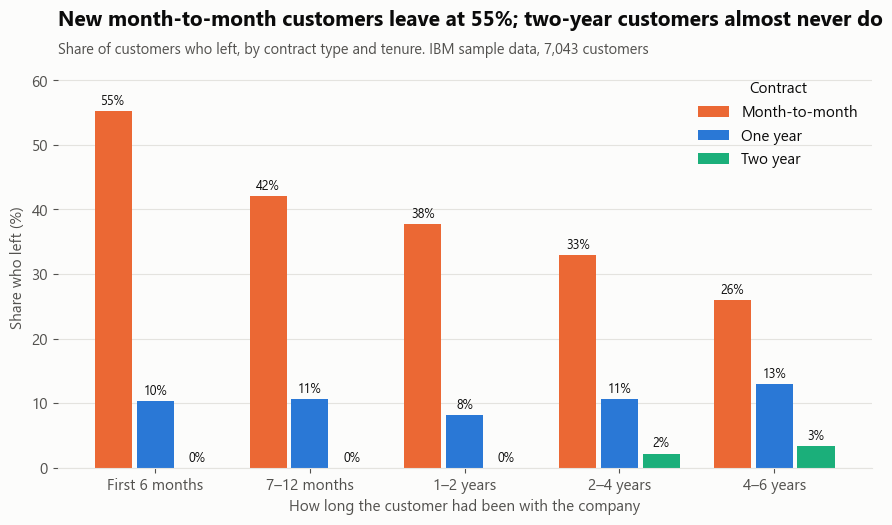

In [4]:
bands = ["0-6 months", "7-12 months", "1-2 years", "2-4 years", "4-6 years"]
contracts = ["Month-to-month", "One year", "Two year"]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
w = 0.27
colours = {"Month-to-month": ORANGE, "One year": BLUE, "Two year": AQUA}
for j, c in enumerate(contracts):
    sub = ct[ct.contract == c].set_index("tenure_band").reindex(bands)
    bars = ax.bar(np.arange(5) + (j - 1) * w, sub.churn_rate_pct, width=w - 0.03, color=colours[c], label=c)
    for b, v in zip(bars, sub.churn_rate_pct):
        ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}%", ha="center", fontsize=9, color=INK)
ax.set_xticks(np.arange(5), ["First 6 months", "7–12 months", "1–2 years", "2–4 years", "4–6 years"])
ax.set_xlabel("How long the customer had been with the company")
ax.set_ylabel("Share who left (%)")
ax.set_ylim(0, 62)
ax.grid(axis="x", visible=False)
ax.legend(title="Contract", loc="upper right")
titles(ax, "New month-to-month customers leave at 55%; two-year customers almost never do",
       "Share of customers who left, by contract type and tenure. IBM sample data, 7,043 customers")
save(fig, "01_who_leaves.png")
plt.show()

In [5]:
sql("SELECT * FROM mart_revenue_at_risk")

,contract,customers,monthly_revenue,monthly_revenue_lost,pct_revenue_lost,share_of_all_lost_revenue
0,Month-to-month,3875,257294.0,120847.0,47.0,86.9
1,One year,1473,95817.0,14118.0,14.7,10.1
2,Two year,1695,103006.0,4165.0,4.0,3.0


In [6]:
sql("SELECT * FROM mart_churn_by_feature WHERE feature IN ('Payment method', 'Internet service', 'Tech support', 'Senior citizen')")

,feature,value,customers,churn_rate_pct,avg_monthly_charges,index_vs_average
0,Internet service,Fiber optic,3096,41.9,91.50,158.0
1,Internet service,DSL,2421,19.0,58.10,71.0
2,Internet service,No,1526,7.4,21.08,28.0
3,Payment method,Electronic check,2365,45.3,76.26,171.0
4,Payment method,Mailed check,1612,19.1,43.92,72.0
5,Payment method,Bank transfer (automatic),1544,16.7,67.19,63.0
6,Payment method,Credit card (automatic),1522,15.2,66.51,57.0
7,Senior citizen,Yes,1142,41.7,79.82,157.0
8,Senior citizen,No,5901,23.6,61.85,89.0
9,Tech support,No,3473,41.6,74.59,157.0


Electronic-cheque payers (45%), fibre-optic customers (42%) and customers without tech support (42%) also leave
far more often than average (26.5%). Many of these overlap, which is what a model sorts out.

## 3. Predicting who will leave

Three models, each scored on **out-of-fold** predictions (5-fold cross-validation), so every customer's
probability comes from a model that never saw them.

In [7]:
candidates = models()
oof = {name: out_of_fold(m, X, y) for name, m in candidates.items()}
scores = pd.DataFrame({name: {"ROC AUC": roc_auc_score(y, p), "Average precision": average_precision_score(y, p),
                              "Brier score (lower is better)": brier_score_loss(y, p)} for name, p in oof.items()}).T
scores.round(4)

,ROC AUC,Average precision,Brier score (lower is better)
Logistic regression,0.8433,0.6502,0.1360
Random forest,0.8454,0.6514,0.1356
Gradient boosting,0.8404,0.6521,0.1373


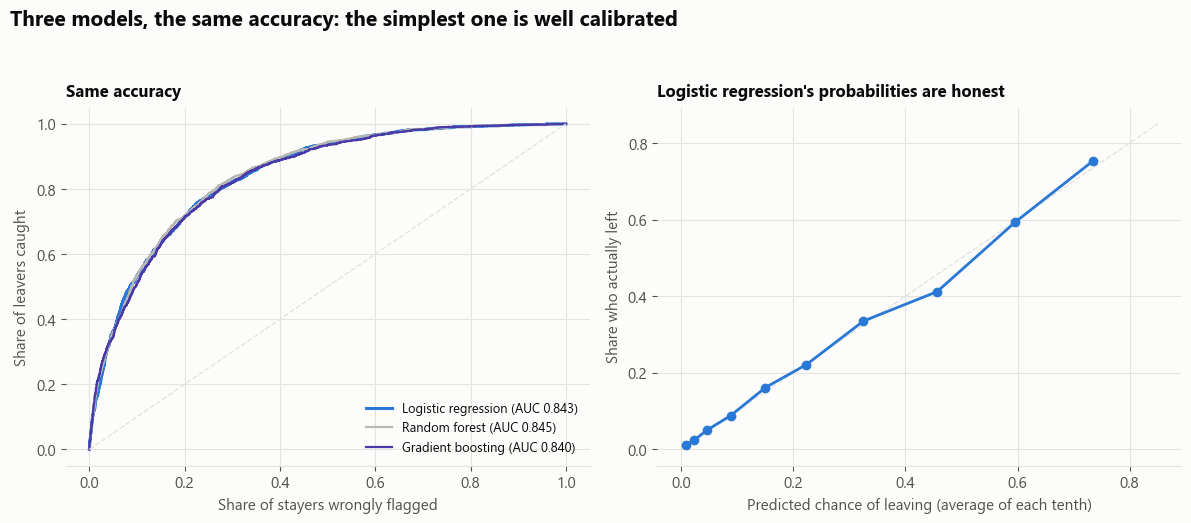

In [8]:
p = oof["Logistic regression"]
deciles = pd.DataFrame({"predicted": p, "actual": y}).groupby(pd.qcut(p, 10), observed=True).mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
for (name, probs), colour in zip(oof.items(), [BLUE, NEUTRAL, VIOLET]):
    fpr, tpr, _ = roc_curve(y, probs)
    ax.plot(fpr, tpr, color=colour, lw=2.2 if name == "Logistic regression" else 1.6,
            label=f"{name} (AUC {roc_auc_score(y, probs):.3f})")
ax.plot([0, 1], [0, 1], color=GRID, lw=1, ls="--")
ax.set_xlabel("Share of stayers wrongly flagged")
ax.set_ylabel("Share of leavers caught")
ax.set_title("Same accuracy", fontsize=12, pad=8)
ax.legend(loc="lower right", fontsize=9.3)
ax = axes[1]
ax.plot([0, 0.85], [0, 0.85], color=GRID, lw=1, ls="--")
ax.plot(deciles.predicted, deciles.actual, color=BLUE, marker="o", lw=2)
ax.set_xlabel("Predicted chance of leaving (average of each tenth)")
ax.set_ylabel("Share who actually left")
ax.set_title("Logistic regression's probabilities are honest", fontsize=12, pad=8)
fig.suptitle("Three models, the same accuracy: the simplest one is well calibrated", x=0.01, ha="left",
             fontsize=15, fontweight="bold", y=1.04)
fig.tight_layout()
save(fig, "02_models.png")
plt.show()

The random forest's AUC is 0.002 higher, a difference far smaller than the noise between folds. Logistic
regression is easier to explain, and when it says "40%", about 40% of those customers really leave. That
calibration matters, because the next step multiplies the probability by money.

**What drives the predictions?** Permutation importance: shuffle one column at a time on held-out customers and
measure how much the AUC drops.

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
lr = models()["Logistic regression"].fit(X_tr, y_tr)
imp = permutation_importance(lr, X_te, y_te, scoring="roc_auc", n_repeats=30, random_state=0)
importance = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False)
importance.head(10).round(4)

tenure             0.0842
InternetService    0.0437
Contract           0.0331
MonthlyCharges     0.0196
StreamingMovies    0.0044
StreamingTV        0.0042
PaymentMethod      0.0040
OnlineSecurity     0.0034
TechSupport        0.0033
MultipleLines      0.0026
dtype: float64

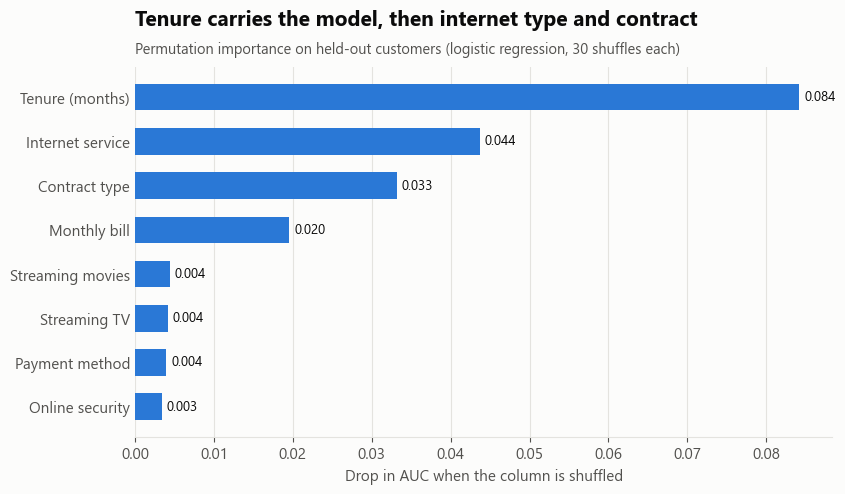

In [10]:
top = importance.head(8)[::-1]
labels = {"tenure": "Tenure (months)", "Contract": "Contract type", "InternetService": "Internet service",
          "MonthlyCharges": "Monthly bill", "TotalCharges": "Total billed", "PaymentMethod": "Payment method",
          "TechSupport": "Tech support", "OnlineSecurity": "Online security", "PaperlessBilling": "Paperless billing",
          "StreamingMovies": "Streaming movies", "StreamingTV": "Streaming TV", "MultipleLines": "Multiple lines"}
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh([labels.get(i, i) for i in top.index], top.values, color=BLUE, height=0.6)
for yv, v in enumerate(top.values):
    ax.text(v + 0.0006, yv, f"{v:.3f}", va="center", fontsize=9.5, color=INK)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Drop in AUC when the column is shuffled")
titles(ax, "Tenure carries the model, then internet type and contract",
       "Permutation importance on held-out customers (logistic regression, 30 shuffles each)")
save(fig, "03_drivers.png")
plt.show()

## 4. From probabilities to decisions

**The offer** (assumptions: change them in `src/churn.py`):
- a one-off **$60 credit**, about one average monthly bill, which everyone who gets it uses;
- it keeps **30%** of the customers who would otherwise have left;
- a kept customer stays **12 more months** on average, at a **60% margin** on their bill.

So keeping a customer who pays $100 a month is worth 12 × 0.6 × $100 = $720, and sending them the offer is worth
risk × 0.3 × $720 − $60. That's positive when their risk is above 28%. For a customer paying $30 a month, the risk
would have to be above 93%. **Who's worth targeting depends on the bill, not just the risk.**

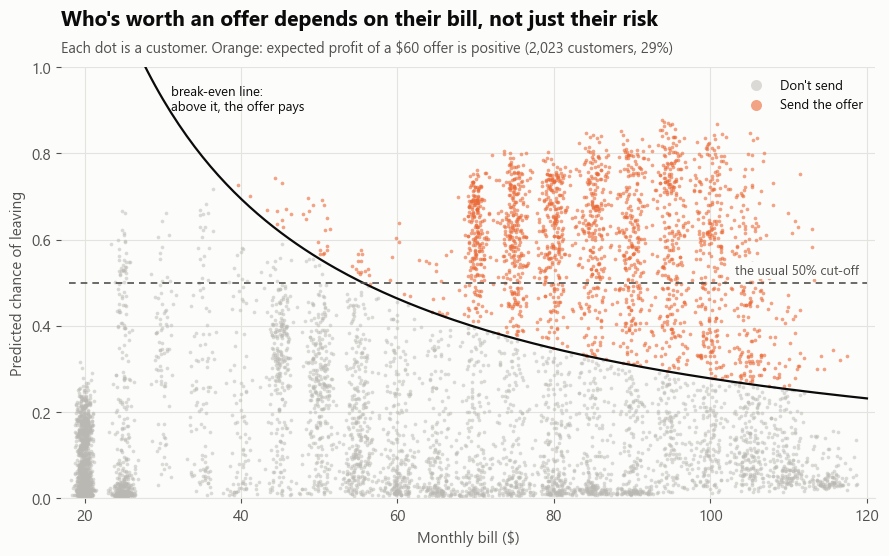

In [11]:
offer = Offer()
bills = X.MonthlyCharges.values
ev = expected_profit(p, bills, offer)
target = ev > 0

fig, ax = plt.subplots(figsize=(10.5, 5.6))
ax.scatter(bills[~target], p[~target], s=7, color=NEUTRAL, alpha=0.5, lw=0, label="Don't send")
ax.scatter(bills[target], p[target], s=7, color=ORANGE, alpha=0.6, lw=0, label="Send the offer")
xs = np.linspace(20, 120, 200)
ax.plot(xs, offer.cost / (offer.success_rate * offer.value_if_saved(xs)), color=INK, lw=1.6)
ax.plot([18, 120], [0.5, 0.5], color=INK_2, lw=1.2, ls=(0, (4, 3)))
ax.text(119, 0.52, "the usual 50% cut-off", ha="right", fontsize=9.5, color=INK_2,
        bbox=dict(fc=SURFACE, ec="none", pad=1.5))
ax.text(31, 0.9, "break-even line:\nabove it, the offer pays", fontsize=9.5, color=INK)
ax.set_ylim(0, 1)
ax.set_xlim(17, 121)
ax.set_xlabel("Monthly bill ($)")
ax.set_ylabel("Predicted chance of leaving")
ax.legend(loc="upper right", markerscale=3, fontsize=9.5)
titles(ax, "Who's worth an offer depends on their bill, not just their risk",
       f"Each dot is a customer. Orange: expected profit of a $60 offer is positive "
       f"({target.sum():,} customers, {target.mean():.0%})")
save(fig, "04_who_to_target.png")
plt.show()

**How much each rule earns**, scored against what customers actually did (out-of-fold predictions, all 7,043
customers):

In [12]:
table = policies(p, y, bills, offer)
table["profit per 1,000 customers"] = table.profit / len(y) * 1000
table.round(2)

,profit,share_targeted,customers_targeted,"profit per 1,000 customers"
Nobody,0.00,0.00,0.0,0.00
Everybody,-122057.36,1.00,7043.0,-17330.31
Risk above 50% (default classifier),85156.93,0.22,1546.0,12091.00
Expected profit above zero,92375.33,0.29,2023.0,13115.91
Perfect hindsight,190413.60,0.24,1721.0,27035.87


In [13]:
rng = np.random.default_rng(0)
gaps = []
for _ in range(2000):
    i = rng.integers(0, len(y), len(y))
    t = policies(p[i], y.values[i], bills[i], offer)
    gaps.append(t.loc["Expected profit above zero", "profit"] - t.loc["Risk above 50% (default classifier)", "profit"])
lo, hi = np.percentile(gaps, [2.5, 97.5])
print(f"extra profit from the expected-profit rule: ${np.mean(gaps):,.0f} (95% bootstrap interval ${lo:,.0f} to ${hi:,.0f})")

extra profit from the expected-profit rule: $7,157 (95% bootstrap interval $2,621 to $11,825)


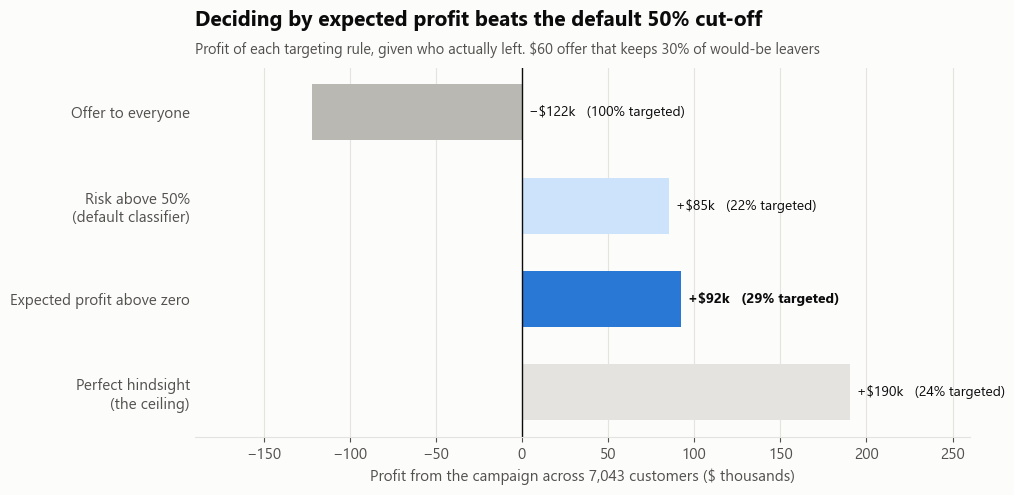

In [14]:
order = ["Everybody", "Risk above 50% (default classifier)", "Expected profit above zero", "Perfect hindsight"]
show = table.loc[order]
fig, ax = plt.subplots(figsize=(10, 4.8))
colours = [NEUTRAL, BLUE_LIGHT, BLUE, GRID]
bars = ax.barh(["Offer to everyone", "Risk above 50%\n(default classifier)", "Expected profit above zero",
                "Perfect hindsight\n(the ceiling)"][::-1], show.profit.values[::-1] / 1000, color=colours[::-1], height=0.6)
for b, v, share, rule in zip(bars, show.profit.values[::-1], show.share_targeted.values[::-1], order[::-1]):
    money = f"{'+' if v >= 0 else '−'}${abs(v) / 1000:,.0f}k"
    ax.text(max(v / 1000, 0) + 4, b.get_y() + b.get_height() / 2, f"{money}   ({share:.0%} targeted)",
            va="center", ha="left", fontsize=10, color=INK, fontweight="bold" if rule.startswith("Expected") else "normal")
ax.axvline(0, color=INK, lw=1)
ax.set_xlim(-190, 260)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Profit from the campaign across 7,043 customers ($ thousands)")
titles(ax, "Deciding by expected profit beats the default 50% cut-off",
       "Profit of each targeting rule, given who actually left. $60 offer that keeps 30% of would-be leavers")
save(fig, "05_rules.png")
plt.show()

## 5. What if the assumptions are wrong?

The offer's cost and success rate are guesses. Re-run every rule for 30 combinations of the two:

In [15]:
rows = []
for cost in [20, 40, 60, 80, 100, 120]:
    for rate in [0.1, 0.2, 0.3, 0.4, 0.5]:
        t = policies(p, y, bills, Offer(cost=cost, success_rate=rate))
        rows.append({"offer cost": cost, "success rate": rate,
                     "expected-profit rule": t.loc["Expected profit above zero", "profit"],
                     "50% rule": t.loc["Risk above 50% (default classifier)", "profit"],
                     "share targeted by profit rule": t.loc["Expected profit above zero", "share_targeted"]})
sens = pd.DataFrame(rows)
sens["extra profit"] = sens["expected-profit rule"] - sens["50% rule"]
print(f"the expected-profit rule wins in {(sens['extra profit'] > 0).sum()} of {len(sens)} scenarios; "
      f"the 50% rule loses money in {(sens['50% rule'] < 0).sum()}")
sens.round(2)

the expected-profit rule wins in 30 of 30 scenarios; the 50% rule loses money in 9


,offer cost,success rate,expected-profit rule,50% rule,share targeted by profit rule,extra profit
0,20,0.1,30791.78,28385.64,0.29,2406.13
1,20,0.2,112912.12,87691.29,0.44,25220.83
2,20,0.3,202642.40,146996.93,0.52,55645.47
3,20,0.4,297652.02,206302.58,0.57,91349.44
4,20,0.5,393392.90,265608.22,0.60,127784.68
5,40,0.1,5460.26,-2534.36,0.10,7994.62
6,40,0.2,61583.55,56771.29,0.29,4812.26
7,40,0.3,137396.17,116076.93,0.37,21319.24
8,40,0.4,225824.24,175382.58,0.44,50441.66
9,40,0.5,315702.20,234688.22,0.49,81013.98


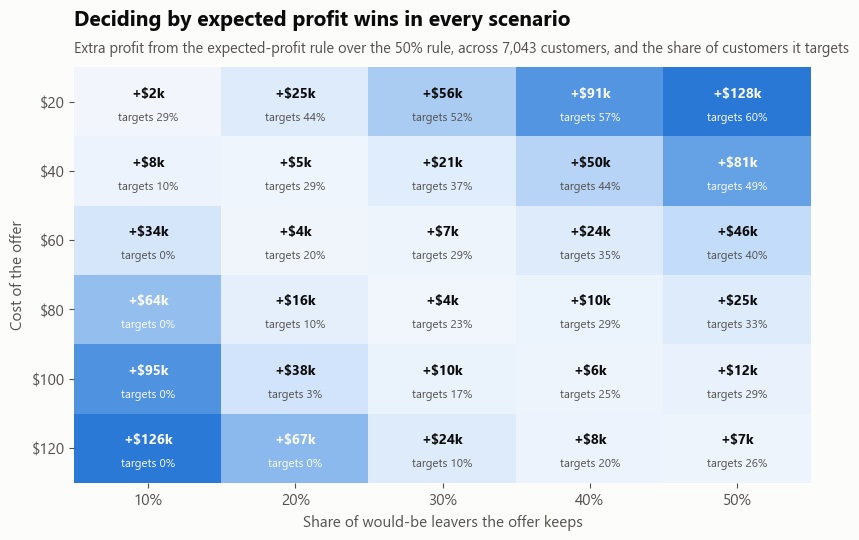

In [16]:
grid = sens.pivot_table(index="offer cost", columns="success rate", values="extra profit") / 1000
share = sens.pivot_table(index="offer cost", columns="success rate", values="share targeted by profit rule")
fig, ax = plt.subplots(figsize=(9.5, 5.4))
from matplotlib.colors import LinearSegmentedColormap  # noqa: E402
cmap = LinearSegmentedColormap.from_list("b", ["#f4f8fd", BLUE_LIGHT, "#5b9be3", BLUE])
im = ax.imshow(grid.values, cmap=cmap, aspect="auto", vmin=0)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        ax.text(j, i - 0.12, f"+${v:,.0f}k", ha="center", va="center", fontsize=10,
                color=SURFACE if v > 60 else INK, fontweight="bold")
        ax.text(j, i + 0.22, f"targets {share.values[i, j]:.0%}", ha="center", va="center", fontsize=8.3,
                color=SURFACE if v > 60 else INK_2)
ax.set_xticks(range(grid.shape[1]), [f"{c:.0%}" for c in grid.columns])
ax.set_yticks(range(grid.shape[0]), [f"${r}" for r in grid.index])
ax.set_xlabel("Share of would-be leavers the offer keeps")
ax.set_ylabel("Cost of the offer")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
titles(ax, "Deciding by expected profit wins in every scenario",
       "Extra profit from the expected-profit rule over the 50% rule, across 7,043 customers, "
       "and the share of customers it targets")
save(fig, "06_sensitivity.png")
plt.show()

The expected-profit rule adapts on its own. With a cheap, effective offer it targets far more customers than the
50% rule. With an expensive one it targets fewer, or no one at all, where the 50% rule would lose money.

## 6. The deliverable: a ranked list with reasons

A list the retention team can use: each customer's risk, the expected profit of contacting them, the decision, and
the main reason the model flags them. The reason is the feature that pushes their risk up most compared with an
average customer, using the logistic regression's coefficients.

In [17]:
final = models()["Logistic regression"].fit(X, y)
prep, model = final.named_steps["prep"], final.named_steps["model"]
Z = prep.transform(X)
Z = Z.toarray() if hasattr(Z, "toarray") else Z
contrib = Z * model.coef_[0]
names = prep.get_feature_names_out()
source = [n.split("__", 1)[1].rsplit("_", 1)[0] if n.startswith("cat__") else n.split("__", 1)[1] for n in names]
by_feature = pd.DataFrame(contrib, columns=names).T.groupby(source).sum().T
by_feature = by_feature - by_feature.mean()


def describe(row_index, feature):
    value = X.iloc[row_index][feature]
    if feature == "tenure":
        return f"Tenure: {value} month{'' if value == 1 else 's'}"
    if feature == "MonthlyCharges":
        return f"Monthly bill: ${value:.0f}"
    if feature == "SeniorCitizen":
        return "Senior citizen" if value == 1 else "Not a senior"
    return f"{labels.get(feature, feature)}: {value}"


top2 = np.argsort(-by_feature.values, axis=1)[:, :2]
reason_1 = [describe(i, by_feature.columns[j[0]]) for i, j in enumerate(top2)]
reason_2 = [describe(i, by_feature.columns[j[1]]) for i, j in enumerate(top2)]

out = pd.DataFrame({"customer_id": raw.customerID, "churn_probability": p.round(3),
                    "monthly_bill": bills, "expected_profit_of_offer": ev.round(2),
                    "decision": np.where(ev > 0, "send offer", "no offer"),
                    "main_reason": reason_1, "second_reason": reason_2})
out = out.sort_values("expected_profit_of_offer", ascending=False)
(ROOT / "data" / "output").mkdir(parents=True, exist_ok=True)
out.to_csv(ROOT / "data" / "output" / "retention_targets.csv", index=False)
out.head(10)

,customer_id,churn_probability,monthly_bill,expected_profit_of_offer,decision,main_reason,second_reason
5933,6496-SLWHQ,0.846,105.00,131.96,send offer,Tenure: 3 months,Internet service: Fiber optic
6894,1400-MMYXY,0.836,105.90,131.33,send offer,Tenure: 3 months,Internet service: Fiber optic
4826,3389-YGYAI,0.830,105.50,129.21,send offer,Tenure: 8 months,Internet service: Fiber optic
2208,7216-EWTRS,0.868,100.80,128.97,send offer,Tenure: 1 month,Internet service: Fiber optic
6482,5419-JPRRN,0.844,101.45,124.97,send offer,Tenure: 1 month,Internet service: Fiber optic
261,3606-TWKGI,0.801,106.90,124.94,send offer,Tenure: 13 months,Internet service: Fiber optic
6365,8884-ADFVN,0.837,101.95,124.34,send offer,Tenure: 7 months,Internet service: Fiber optic
905,0781-LKXBR,0.842,100.50,122.83,send offer,Tenure: 9 months,Internet service: Fiber optic
1026,4822-RVYBB,0.834,100.60,121.15,send offer,Tenure: 8 months,Internet service: Fiber optic
3956,4587-VVTOX,0.796,105.30,120.99,send offer,Tenure: 6 months,Internet service: Fiber optic


In [18]:
out[out.decision == "send offer"].main_reason.str.split(":").str[0].value_counts()

main_reason
Tenure              1206
Internet service     813
Contract type          4
Name: count, dtype: int64

## 7. Limitations
- **The data is IBM's sample for a fictional company**: realistic patterns, not a real business.
- **The offer economics are assumptions.** The sensitivity grid shows the method holds across a wide range, but a
  real campaign should measure the success rate with a holdout group (an A/B test).
- **The data is a snapshot:** it can't show *when* customers leave, so it can't time the offer. A survival model on
  monthly data would.
- **Profit is scored on out-of-fold predictions** for all customers. A fresh period of data would be a stricter test.